# 1. Ground Truth Sentiment Labeling

This notebook labels our collected data with ground truth sentiment using **three top-tier LLM annotators** via OpenRouter:

| Annotator | Model ID |
|-----------|----------|
| GPT-4o Mini | `openai/gpt-4o-mini` |
| Gemini 2.5 Flash | `google/gemini-2.5-flash` |
| Claude 3.5 Haiku | `anthropic/claude-3.5-haiku` |

Each text is classified as **positive**, **negative**, or **neutral**.  
Inter-annotator agreement is measured using **Fleiss' Kappa**.

## 1. Setup & Imports

In [27]:
import os
import time
import logging
import pandas as pd
import numpy as np
import requests
from typing import Optional
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

## 2. Configuration

In [ ]:
# ──────────────────────────────────────────────
# API KEY  (paste your OpenRouter key here)
# ──────────────────────────────────────────────
OPENROUTER_API_KEY = "OPENROUTER_API_KEY"
OPENROUTER_URL     = "https://openrouter.ai/api/v1"

# ──────────────────────────────────────────────
# Three annotator models
# ──────────────────────────────────────────────
MODELS = {
    "gpt4o_mini":      "openai/gpt-4o-mini",
    "gemini_flash":    "google/gemini-2.5-flash",
    "claude_haiku":    "anthropic/claude-3.5-haiku",
}

# ──────────────────────────────────────────────
# Rate-limit safety settings
# ──────────────────────────────────────────────
BATCH_SIZE            = 5      # texts per batch
DELAY_BETWEEN_CALLS   = 1.5    # seconds between individual API calls
DELAY_BETWEEN_BATCHES = 10     # seconds between batches
MAX_RETRIES           = 3      # retries on transient errors
RETRY_BACKOFF         = 5      # extra seconds added per retry

# ──────────────────────────────────────────────
# I/O
# ──────────────────────────────────────────────
INPUT_CSV  = "Cleaned_Iran_War_Sentiment.csv"
OUTPUT_CSV = "Cleaned_Iran_War_Sentiment_with_Sentiment_Labels.csv"

print("Configuration loaded.")
print(f"Models: {list(MODELS.keys())}")

Configuration loaded.
Models: ['gpt4o_mini', 'gemini_flash', 'claude_haiku']


## 3. Load Data

In [29]:
df = pd.read_csv(INPUT_CSV)
texts = df['final_text'].tolist()

print(f"Loaded {len(df)} rows.")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 500 rows.
Columns: ['created_at', 'username', 'sentiment_text', 'url', 'subject_tag', 'stance_category', 'final_text']


,created_at,username,sentiment_text,url,subject_tag,stance_category,final_text
0,2026-03-07T23:29:46.949Z,tuckfrump,#Belgium #operationepicfailure #iran #iranwar ...,https://mastodon.social/@tuckfrump/11619049058...,Military Action,Neutral,belgium also say trumps war besides spain coun...
1,2026-03-07T23:22:20.068Z,RonSupportsYou,&quot;Massive war price tag could be a massive...,https://mastodon.social/@RonSupportsYou/116190...,General Conflict,Neutral,massive war price tag could massive problem to...
2,2026-03-07T23:12:15.293Z,RonSupportsYou,"You, @noncompliant, wrote: &quot;American sold...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Anti-Iran,write american soldier kill innocent woman chi...
3,2026-03-07T23:05:16.000Z,AntiracistHippie,NOW ON VERDANT SQUARE RADIO == NOW PLAYING == ...,https://heads.social/@AntiracistHippie/1161903...,General Conflict,Neutral,verdant square radio playing note bowie hawkin...
4,2026-03-07T23:04:35.828Z,RonSupportsYou,"&quot;One gets away with doing reckless, stupi...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Neutral,one get away reckless stupid thing like attack...


## 4. Logging Setup

In [30]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("ground_truth_labeling")
log.info("Logger ready.")

13:44:00 [INFO] Logger ready.


## 5. Prompt Engineering

The system prompt instructs the model to output exactly one of three labels:  
**positive**, **negative**, or **neutral**.

In [31]:
SYSTEM_PROMPT = """You are a precise text classifier. Your task is to label text snippets
according to their overall sentiment.

Labels:
  positive  – The text expresses a favorable, optimistic, supportive, or hopeful tone.
  negative  – The text expresses a critical, hostile, pessimistic, angry, or fearful tone.
  neutral   – The text is factual, balanced, or does not express a clear sentiment.

Rules:
  • Respond with ONLY one of the three labels: positive, negative, or neutral.
  • Do NOT include any explanation, punctuation, or extra words.
  • If the text is ambiguous, prefer neutral."""


def build_user_prompt(text: str) -> str:
    return f'Classify the overall sentiment of the following text:\n\n"""\n{text}\n"""'


print("System prompt:")
print(SYSTEM_PROMPT)

System prompt:
You are a precise text classifier. Your task is to label text snippets
according to their overall sentiment.

Labels:
  positive  – The text expresses a favorable, optimistic, supportive, or hopeful tone.
  negative  – The text expresses a critical, hostile, pessimistic, angry, or fearful tone.
  neutral   – The text is factual, balanced, or does not express a clear sentiment.

Rules:
  • Respond with ONLY one of the three labels: positive, negative, or neutral.
  • Do NOT include any explanation, punctuation, or extra words.
  • If the text is ambiguous, prefer neutral.


## 6. API Helper Functions

In [32]:
# ──────────────────────────────────────────────
# Valid labels
# ──────────────────────────────────────────────
VALID_LABELS = {"positive", "negative", "neutral"}


def _headers() -> dict:
    """
    Build request headers for OpenRouter.
    HTTP-Referer is intentionally omitted to avoid
    CDN/proxy redirects returning HTML.
    """
    return {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type":  "application/json",
        "X-Title":        "Sentiment Ground Truth Annotator",
    }


def verify_connection() -> None:
    """
    Preflight check: calls GET /api/v1/models to catch
    bad keys, network errors, and wrong model IDs early.
    """
    url = f"{OPENROUTER_URL}/models"
    log.info("Verifying OpenRouter connection (%s) ...", url)

    try:
        r = requests.get(url, headers=_headers(), timeout=15)
    except requests.exceptions.RequestException as exc:
        raise RuntimeError(f"Could not reach OpenRouter: {exc}") from exc

    if r.text.strip().startswith("<!DOCTYPE") or r.text.strip().startswith("<html"):
        raise RuntimeError(
            "OpenRouter returned an HTML page instead of JSON.\n"
            "This almost always means the API key is invalid or missing.\n"
            f"  Current key prefix: {repr(OPENROUTER_API_KEY[:16])}\n"
            "  Valid keys look like: sk-or-v1-...\n"
            "  Generate a new key at: https://openrouter.ai/keys"
        )

    if r.status_code == 401:
        raise RuntimeError(
            "OpenRouter returned 401 Unauthorized.\n"
            f"  Current key prefix: {repr(OPENROUTER_API_KEY[:16])}\n"
            "  Generate a new key at: https://openrouter.ai/keys"
        )

    if not r.ok:
        raise RuntimeError(
            f"OpenRouter preflight failed: HTTP {r.status_code}\n{r.text[:300]}"
        )

    models = [m["id"] for m in r.json().get("data", [])]
    log.info("Connection OK. %d models available.", len(models))

    for key, model_id in MODELS.items():
        if model_id not in models:
            log.warning(
                "  [!] %s = '%s' not found in model list. "
                "Check the ID or your account's enabled models.",
                key, model_id,
            )
        else:
            log.info("  [OK] %s = '%s'", key, model_id)


# Run preflight check
verify_connection()

13:44:00 [INFO] Verifying OpenRouter connection (https://openrouter.ai/api/v1/models) ...
13:44:01 [INFO] Connection OK. 350 models available.
13:44:01 [INFO]   [OK] gpt4o_mini = 'openai/gpt-4o-mini'
13:44:01 [INFO]   [OK] gemini_flash = 'google/gemini-2.5-flash'
13:44:01 [INFO]   [OK] claude_haiku = 'anthropic/claude-3.5-haiku'


## 7. API Call Function

In [33]:
def call_openrouter(text: str, model: str) -> Optional[str]:
    """
    Call OpenRouter chat completions and return a validated
    sentiment label (positive / negative / neutral),
    or None if all retries are exhausted.
    """
    url = f"{OPENROUTER_URL}/chat/completions"
    payload = {
        "model":       model,
        "max_tokens":  10,
        "temperature": 0,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": build_user_prompt(text)},
        ],
    }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                url, headers=_headers(), json=payload, timeout=30
            )

            # -- Rate limited ------------------------------------------------
            if response.status_code == 429:
                wait = RETRY_BACKOFF * attempt
                log.warning(
                    "Rate limited (429). Waiting %ds before retry %d/%d ...",
                    wait, attempt, MAX_RETRIES,
                )
                time.sleep(wait)
                continue

            # -- Capture raw text before any parsing -------------------------
            raw_text = response.text.strip()

            # -- HTML page = auth / redirect error ---------------------------
            if raw_text.startswith("<!DOCTYPE") or raw_text.startswith("<html"):
                log.error(
                    "Received HTML instead of JSON (HTTP %d). "
                    "API key is likely invalid. Aborting this call.",
                    response.status_code,
                )
                return None

            # -- Empty body --------------------------------------------------
            if not raw_text:
                log.warning(
                    "Empty response (HTTP %d) attempt %d/%d for %s.",
                    response.status_code, attempt, MAX_RETRIES, model,
                )
                time.sleep(RETRY_BACKOFF * attempt)
                continue

            # -- Non-2xx (not 429) -------------------------------------------
            if not response.ok:
                log.warning(
                    "HTTP %d attempt %d/%d for %s -- body: %.300s",
                    response.status_code, attempt, MAX_RETRIES, model, raw_text,
                )
                if response.status_code < 500:
                    return None  # 4xx won't fix on retry
                time.sleep(RETRY_BACKOFF * attempt)
                continue

            # -- Parse JSON --------------------------------------------------
            try:
                data = response.json()
            except ValueError:
                log.warning(
                    "Invalid JSON attempt %d/%d for %s -- raw: %.300s",
                    attempt, MAX_RETRIES, model, raw_text,
                )
                time.sleep(RETRY_BACKOFF * attempt)
                continue

            # -- Extract content ---------------------------------------------
            try:
                raw_label = data["choices"][0]["message"]["content"].strip().lower()
            except (KeyError, IndexError, TypeError) as exc:
                log.warning(
                    "Unexpected response structure attempt %d/%d for %s: %s",
                    attempt, MAX_RETRIES, model, exc,
                )
                time.sleep(RETRY_BACKOFF * attempt)
                continue

            # -- Validate label ----------------------------------------------
            if raw_label not in VALID_LABELS:
                log.warning(
                    "Unexpected label '%s' from %s -- defaulting to 'neutral'",
                    raw_label, model,
                )
                raw_label = "neutral"

            return raw_label

        except requests.exceptions.Timeout:
            log.warning(
                "Timeout attempt %d/%d for %s", attempt, MAX_RETRIES, model
            )
        except requests.exceptions.ConnectionError as exc:
            log.warning(
                "Connection error attempt %d/%d for %s: %s",
                attempt, MAX_RETRIES, model, exc,
            )
        except requests.exceptions.RequestException as exc:
            log.warning(
                "Request error attempt %d/%d for %s: %s",
                attempt, MAX_RETRIES, model, exc,
            )

        time.sleep(RETRY_BACKOFF * attempt)

    log.error("All %d retries exhausted for model %s.", MAX_RETRIES, model)
    return None


print("API call function defined.")

API call function defined.


## 8. Batch Annotation

In [34]:
def annotate_dataframe(df: pd.DataFrame, texts: list) -> pd.DataFrame:
    """
    Annotates every text with all three models.
    Returns a new DataFrame with columns:
        text, label_gpt4o_mini, label_gemini_flash, label_claude_haiku
    """
    results = {
        "text":               [],
        "label_gpt4o_mini":   [],
        "label_gemini_flash": [],
        "label_claude_haiku": [],
    }

    total     = len(texts)
    n_batches = (total + BATCH_SIZE - 1) // BATCH_SIZE

    log.info(
        "Starting annotation: %d texts | %d batches | batch_size=%d",
        total, n_batches, BATCH_SIZE,
    )

    for batch_idx in range(n_batches):
        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, total)
        batch = texts[start:end]

        log.info(
            "-- Batch %d/%d (rows %d-%d) --",
            batch_idx + 1, n_batches, start, end - 1,
        )

        for i, text in enumerate(batch):
            global_idx = start + i
            log.info("  [%d/%d] %.80s ...", global_idx + 1, total, text)

            labels = {}
            for model_key, model_id in MODELS.items():
                label = call_openrouter(text, model_id)
                labels[model_key] = label or "error"
                log.info(
                    "    %-15s (%s) -> %s",
                    model_key, model_id.split("/")[-1], labels[model_key],
                )
                time.sleep(DELAY_BETWEEN_CALLS)

            results["text"].append(text)
            results["label_gpt4o_mini"].append(labels["gpt4o_mini"])
            results["label_gemini_flash"].append(labels["gemini_flash"])
            results["label_claude_haiku"].append(labels["claude_haiku"])

        if batch_idx < n_batches - 1:
            log.info(
                "  Batch done. Sleeping %ds before next batch ...",
                DELAY_BETWEEN_BATCHES,
            )
            time.sleep(DELAY_BETWEEN_BATCHES)

    return pd.DataFrame(results)


print("Batch annotation function defined.")

Batch annotation function defined.


## 9. Run Annotation

In [43]:
import os

label_col_map = {
    "label_gpt4o_mini":   "gpt4o_mini",
    "label_gemini_flash": "gemini_flash",
    "label_claude_haiku": "claude_haiku",
}

if os.path.exists(OUTPUT_CSV):
    print(f"Found existing {OUTPUT_CSV}, loading...")
    df_labeled = pd.read_csv(OUTPUT_CSV)
    
    # Check for error values and re-annotate those rows
    for col, model_key in label_col_map.items():
        error_mask = df_labeled[col] == "error"
        error_count = error_mask.sum()
        if error_count > 0:
            print(f"  Found {error_count} errors in {col}, re-annotating...")
            model_id = MODELS[model_key]
            for idx in df_labeled[error_mask].index:
                text = df_labeled.loc[idx, "final_text"]
                label = call_openrouter(text, model_id)
                df_labeled.loc[idx, col] = label or "error"
                log.info("  Row %d -> %s", idx, df_labeled.loc[idx, col])
                time.sleep(DELAY_BETWEEN_CALLS)
    
    remaining_errors = df_labeled[list(label_col_map.keys())].isin(["error"]).sum().sum()
    print(f"\nLoaded {len(df_labeled)} rows. Remaining errors: {remaining_errors}")
else:
    df_labeled = annotate_dataframe(df, texts)
    print(f"\nAnnotation complete! {len(df_labeled)} rows labeled.")

df_labeled.head()


Found existing Cleaned_Iran_War_Sentiment_with_Sentiment_Labels.csv, loading...
  Found 1 errors in label_claude_haiku, re-annotating...


13:45:13 [WARNING] HTTP 403 attempt 1/3 for anthropic/claude-3.5-haiku -- body: {"error":{"message":"anthropic/claude-3-5-haiku requires moderation on Amazon Bedrock. Your input was flagged for \"sexual/minors\". No credits were charged.","code":403,"metadata":{"reasons":["sexual/minors"],"flagged_input":"You are a precise text classifier. Your task is to...llon gas trump want 
13:45:13 [INFO]   Row 73 -> error



Loaded 500 rows. Remaining errors: 1


,created_at,username,sentiment_text,url,subject_tag,stance_category,final_text,label_gpt4o_mini,label_gemini_flash,label_claude_haiku,ground_truth
0,2026-03-07T23:29:46.949Z,tuckfrump,#Belgium #operationepicfailure #iran #iranwar ...,https://mastodon.social/@tuckfrump/11619049058...,Military Action,Neutral,belgium also say trumps war besides spain coun...,negative,negative,neutral,negative
1,2026-03-07T23:22:20.068Z,RonSupportsYou,&quot;Massive war price tag could be a massive...,https://mastodon.social/@RonSupportsYou/116190...,General Conflict,Neutral,massive war price tag could massive problem to...,negative,negative,negative,negative
2,2026-03-07T23:12:15.293Z,RonSupportsYou,"You, @noncompliant, wrote: &quot;American sold...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Anti-Iran,write american soldier kill innocent woman chi...,negative,negative,negative,negative
3,2026-03-07T23:05:16.000Z,AntiracistHippie,NOW ON VERDANT SQUARE RADIO == NOW PLAYING == ...,https://heads.social/@AntiracistHippie/1161903...,General Conflict,Neutral,verdant square radio playing note bowie hawkin...,neutral,neutral,neutral,neutral
4,2026-03-07T23:04:35.828Z,RonSupportsYou,"&quot;One gets away with doing reckless, stupi...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Neutral,one get away reckless stupid thing like attack...,negative,negative,neutral,negative


## 10. Label Distribution per Model

Inspect how each model distributed its labels.

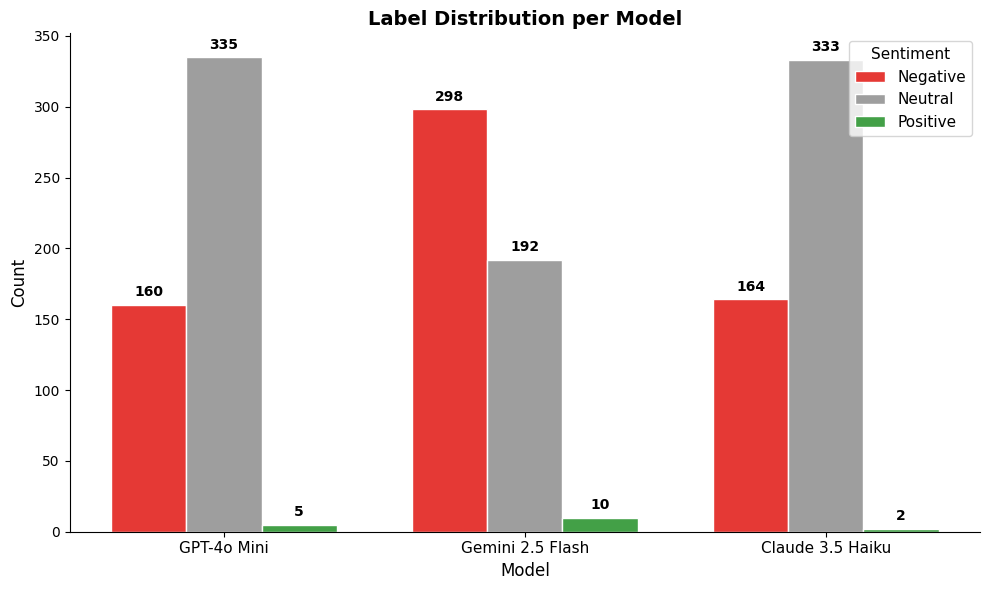

In [44]:
import matplotlib.pyplot as plt

label_cols = ["label_gpt4o_mini", "label_gemini_flash", "label_claude_haiku"]
model_names = ["GPT-4o Mini", "Gemini 2.5 Flash", "Claude 3.5 Haiku"]
categories = ["negative", "neutral", "positive"]
cat_colors = {"negative": "#E53935", "neutral": "#9E9E9E", "positive": "#43A047"}

# Build counts: for each sentiment, get count per model
counts = {}
for cat in categories:
    counts[cat] = [df_labeled[col].value_counts().get(cat, 0) for col in label_cols]

# Plot clustered bar chart
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, cat in enumerate(categories):
    bars = ax.bar(x + i * width, counts[cat], width, label=cat.capitalize(), color=cat_colors[cat], edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Label Distribution per Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(title='Sentiment', fontsize=11, title_fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('label_distribution_per_model.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Inter-Annotator Agreement – Fleiss' Kappa

We treat the three models as three independent annotators and compute
[Fleiss' Kappa](https://en.wikipedia.org/wiki/Fleiss%27_kappa) to measure their
level of agreement.

| Kappa Range | Interpretation |
|-------------|----------------|
| < 0.00 | Poor agreement |
| 0.00 – 0.20 | Slight agreement |
| 0.21 – 0.40 | Fair agreement |
| 0.41 – 0.60 | Moderate agreement |
| 0.61 – 0.80 | Substantial agreement |
| 0.81 – 1.00 | Almost perfect agreement |

In [45]:
# ──────────────────────────────────────────────
# Prepare data for Fleiss' Kappa
# ──────────────────────────────────────────────

# Filter out rows where any annotator returned "error"
df_valid = df_labeled[
    ~df_labeled[label_cols].isin(["error"]).any(axis=1)
].copy()

print(f"Valid rows (no errors): {len(df_valid)} / {len(df_labeled)}")

# Encode labels as integers
label_to_int = {"positive": 0, "negative": 1, "neutral": 2}

# Build the ratings matrix: each row = one item, each column = one rater
ratings = df_valid[label_cols].replace(label_to_int).values

print(f"\nRatings matrix shape: {ratings.shape}")
print(f"  (rows = items, columns = annotators)")
print(f"\nFirst 5 rows of ratings matrix:")
print(ratings[:5])

Valid rows (no errors): 499 / 500

Ratings matrix shape: (499, 3)
  (rows = items, columns = annotators)

First 5 rows of ratings matrix:
[[1 1 2]
 [1 1 1]
 [1 1 1]
 [2 2 2]
 [1 1 2]]


In [46]:
# ──────────────────────────────────────────────
# Compute Fleiss' Kappa
# ──────────────────────────────────────────────

# aggregate_raters converts the n×r matrix into the
# format required by fleiss_kappa (n×k category counts)
table, categories = aggregate_raters(ratings)

kappa = fleiss_kappa(table, method='fleiss')

print("=" * 50)
print("FLEISS' KAPPA RESULTS")
print("=" * 50)
print(f"\nFleiss' Kappa: {kappa:.4f}")
print(f"Categories used: {categories}")
print(f"Number of items: {table.shape[0]}")
print(f"Number of raters: 3")

# Interpretation
if kappa < 0:
    interpretation = "Poor agreement (less than chance)"
elif kappa <= 0.20:
    interpretation = "Slight agreement"
elif kappa <= 0.40:
    interpretation = "Fair agreement"
elif kappa <= 0.60:
    interpretation = "Moderate agreement"
elif kappa <= 0.80:
    interpretation = "Substantial agreement"
else:
    interpretation = "Almost perfect agreement"

print(f"\nInterpretation: {interpretation}")

FLEISS' KAPPA RESULTS

Fleiss' Kappa: 0.4759
Categories used: [0 1 2]
Number of items: 499
Number of raters: 3

Interpretation: Moderate agreement


In [47]:
# ──────────────────────────────────────────────
# Pairwise Fleiss' Kappa (each pair of models)
# ──────────────────────────────────────────────
from itertools import combinations

pair_names = {
    "label_gpt4o_mini":   "GPT-4o Mini",
    "label_gemini_flash": "Gemini 2.5 Flash",
    "label_claude_haiku": "Claude 3.5 Haiku",
}

print("=" * 50)
print("PAIRWISE FLEISS' KAPPA")
print("=" * 50)

for col_a, col_b in combinations(label_cols, 2):
    pair_ratings = df_valid[[col_a, col_b]].replace(label_to_int).values
    pair_table, _ = aggregate_raters(pair_ratings)
    pair_kappa = fleiss_kappa(pair_table, method='fleiss')
    print(f"\n  {pair_names[col_a]}  vs  {pair_names[col_b]}:  κ = {pair_kappa:.4f}")

print()


PAIRWISE FLEISS' KAPPA

  GPT-4o Mini  vs  Gemini 2.5 Flash:  κ = 0.4092

  GPT-4o Mini  vs  Claude 3.5 Haiku:  κ = 0.6146

  Gemini 2.5 Flash  vs  Claude 3.5 Haiku:  κ = 0.3946



## 12. Majority Vote – Final Ground Truth Label

Since we have 3 annotators, a simple **majority vote** (≥ 2 agree) determines the final label.

In [48]:
from collections import Counter

def majority_vote(row):
    """Return the label that at least 2 of 3 annotators agree on."""
    votes = [row["label_gpt4o_mini"], row["label_gemini_flash"], row["label_claude_haiku"]]
    counts = Counter(votes)
    most_common_label, most_common_count = counts.most_common(1)[0]
    return most_common_label


df_labeled["ground_truth"] = df_labeled.apply(majority_vote, axis=1)

print("Ground Truth Label Distribution (Majority Vote):")
print(df_labeled["ground_truth"].value_counts())
print()

# Show agreement rate
unanimous = df_labeled.apply(
    lambda r: r["label_gpt4o_mini"] == r["label_gemini_flash"] == r["label_claude_haiku"],
    axis=1,
).sum()
print(f"Unanimous agreement (all 3 models agree): {unanimous}/{len(df_labeled)} ({unanimous/len(df_labeled)*100:.1f}%)")

df_labeled.head(10)

Ground Truth Label Distribution (Majority Vote):
ground_truth
neutral     300
negative    195
positive      5
Name: count, dtype: int64

Unanimous agreement (all 3 models agree): 304/500 (60.8%)


,created_at,username,sentiment_text,url,subject_tag,stance_category,final_text,label_gpt4o_mini,label_gemini_flash,label_claude_haiku,ground_truth
0,2026-03-07T23:29:46.949Z,tuckfrump,#Belgium #operationepicfailure #iran #iranwar ...,https://mastodon.social/@tuckfrump/11619049058...,Military Action,Neutral,belgium also say trumps war besides spain coun...,negative,negative,neutral,negative
1,2026-03-07T23:22:20.068Z,RonSupportsYou,&quot;Massive war price tag could be a massive...,https://mastodon.social/@RonSupportsYou/116190...,General Conflict,Neutral,massive war price tag could massive problem to...,negative,negative,negative,negative
2,2026-03-07T23:12:15.293Z,RonSupportsYou,"You, @noncompliant, wrote: &quot;American sold...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Anti-Iran,write american soldier kill innocent woman chi...,negative,negative,negative,negative
3,2026-03-07T23:05:16.000Z,AntiracistHippie,NOW ON VERDANT SQUARE RADIO == NOW PLAYING == ...,https://heads.social/@AntiracistHippie/1161903...,General Conflict,Neutral,verdant square radio playing note bowie hawkin...,neutral,neutral,neutral,neutral
4,2026-03-07T23:04:35.828Z,RonSupportsYou,"&quot;One gets away with doing reckless, stupi...",https://mastodon.social/@RonSupportsYou/116190...,Military Action,Neutral,one get away reckless stupid thing like attack...,negative,negative,neutral,negative
5,2026-03-07T22:46:52.000Z,saskboy,Peace Prize Pedo President is poised to push p...,https://mastodon.cc/@saskboy/116190321877388892,General Conflict,Anti-Iran,peace prize pedro president poise push paratro...,neutral,neutral,neutral,neutral
6,2026-03-07T22:45:11.989Z,PoetGreg,#SEVENTEEN #IranIsraelWar #Trump #TrumpEpstein...,https://mastodon.social/@PoetGreg/116190315281...,General Conflict,Neutral,NaN,neutral,neutral,neutral,neutral
7,2026-03-07T21:30:12.000Z,metro.co.uk,Man killed by falling debris after drone hits ...,https://fed.brid.gy/r/https://metro.co.uk/2026...,Military Action,Neutral,man kill fall debris drone hit dubai marina tower,negative,negative,negative,negative
8,2026-03-07T20:45:56.000Z,metro.co.uk,Thousands protest against strikes on Iran at U...,https://fed.brid.gy/r/https://metro.co.uk/2026...,Protest/Activism,Neutral,thousand protest strike iran u embassy london,neutral,negative,negative,negative
9,2026-03-07T22:40:33.000Z,CharlieMcHenry,Trump’s White House Posts Fascist Memes As It ...,https://connectop.us/@CharlieMcHenry/116190297...,General Conflict,Neutral,trump white house post fascist meme wreck econ...,negative,negative,negative,negative


## 13. Save Final Output

In [49]:
# Merge label columns onto original DataFrame and save
df_final = pd.concat([df.reset_index(drop=True), df_labeled[["label_gpt4o_mini", "label_gemini_flash", "label_claude_haiku", "ground_truth"]].reset_index(drop=True)], axis=1)

df_final.to_csv(OUTPUT_CSV, index=False)
print(f"Final labeled data saved to: {OUTPUT_CSV}")
print(f"Total records: {len(df_final)}")
print(f"Columns: {list(df_final.columns)}")


Final labeled data saved to: Cleaned_Iran_War_Sentiment_with_Sentiment_Labels.csv
Total records: 500
Columns: ['created_at', 'username', 'sentiment_text', 'url', 'subject_tag', 'stance_category', 'final_text', 'label_gpt4o_mini', 'label_gemini_flash', 'label_claude_haiku', 'ground_truth']


## 14. Summary

| Item | Value |
|------|-------|
| Total texts annotated | 500 |
| Annotator 1 | GPT-4o Mini (`openai/gpt-4o-mini`) |
| Annotator 2 | Gemini 2.5 Flash (`google/gemini-2.5-flash`) |
| Annotator 3 | Claude 3.5 Haiku (`anthropic/claude-3.5-haiku`) |
| Label scheme | positive / negative / neutral |
| Agreement metric | Fleiss' Kappa |
| Final label method | Majority vote (≥ 2/3 agree) |